In [1]:
import pandas as pd
import numpy as np
import os

np.random.seed(42)

n = 10000

# Generate base distributions
attendance = np.random.normal(75, 15, n).clip(0, 100)
study_hours = np.random.normal(4, 2, n).clip(0, 24)
sleep_hours = np.random.normal(7, 1.5, n).clip(0, 24)
stress_level = np.random.normal(5, 2, n).clip(1, 10).round()

# Introduce correlations
# High study & good sleep & high attendance -> Higher CGPA
cgpa_base = 3.0 + (study_hours/24)*3.0 + (attendance/100)*2.0 + (sleep_hours/10)*1.0 - (stress_level/10)*1.0
previous_cgpa = (cgpa_base + np.random.normal(0, 0.5, n)).clip(0, 10).round(2)

# Backlogs are inversely proportional to CGPA
backlog_prob = np.clip(1.0 - previous_cgpa/10, 0, 1)
backlogs = np.random.binomial(10, backlog_prob*0.3, n) # max 10

# Academic marks depend heavily on previous_cgpa, study_hours, and attendance
academic_factor = (previous_cgpa/10)*0.5 + (study_hours/24)*0.3 + (attendance/100)*0.2

internals = np.random.normal(academic_factor * 30, 3, n).clip(0, 30).astype(int)
assignments = np.random.normal(academic_factor * 20, 2, n).clip(0, 20).astype(int)
viva = np.random.normal(academic_factor * 10, 1.5, n).clip(0, 10).astype(int)
lab_marks = np.random.normal(academic_factor * 30, 3, n).clip(0, 30).astype(int)
mid_exam = np.random.normal(academic_factor * 30, 3, n).clip(0, 30).astype(int)

branch = np.random.choice(["CSE", "ECE", "MECH"], n)
year = np.random.randint(1, 5, n)

data = pd.DataFrame({
    "internals": internals,
    "assignments": assignments,
    "viva": viva,
    "lab_marks": lab_marks,
    "mid_exam": mid_exam,
    "attendance": attendance.astype(int),
    "study_hours": study_hours.round(1),
    "backlogs": backlogs,
    "sleep_hours": sleep_hours.round(1),
    "stress_level": stress_level.astype(int),
    "previous_cgpa": previous_cgpa,
    "branch": branch,
    "year": year
})

# Compute final score (out of 100)
total_marks = data["internals"] + data["assignments"] + data["viva"] + data["lab_marks"] + data["mid_exam"]
# Score percentage based on marks (80% weight) and attendance (20% weight)
data["final_score"] = (total_marks / 120 * 80) + (data["attendance"] / 100 * 20)

# Apply penalties for high stress or backlogs
data["final_score"] -= data["stress_level"] * 0.5
data["final_score"] -= data["backlogs"] * 2

# Add some random noise
data["final_score"] += np.random.uniform(-3, 3, n)

# Clamp strictly between 0 and 100
data["final_score"] = data["final_score"].clip(0, 100).round(2)

# Assign grades based on realistic university scales
def get_grade(score):
    if score >= 95:
        return "O"
    elif score >= 90:
        return "A+"
    elif score >= 80:
        return "A"
    elif score >= 70:
        return "B"
    elif score >= 60:
        return "C"
    elif score >= 50:
        return "D"
    else:
        return "FAIL"

data["grade"] = data["final_score"].apply(get_grade)

# Save the dataset locally for the notebook cells to use
data.to_csv("student_performance_dataset.csv", index=False)

print("✅ Realistic Dataset created successfully!")


✅ Realistic Dataset created successfully!


In [2]:
print(data.describe())
print(data.corr(numeric_only=True))

         internals   assignments          viva     lab_marks      mid_exam  \
count  10000.00000  10000.000000  10000.000000  10000.000000  10000.000000   
mean      13.34570      8.678600      4.114800     13.283600     13.303600   
std        3.55984      2.391082      1.649089      3.562421      3.572884   
min        0.00000      0.000000      0.000000      0.000000      1.000000   
25%       11.00000      7.000000      3.000000     11.000000     11.000000   
50%       13.00000      9.000000      4.000000     13.000000     13.000000   
75%       16.00000     10.000000      5.000000     16.000000     16.000000   
max       27.00000     17.000000     10.000000     27.000000     27.000000   

         attendance   study_hours      backlogs  sleep_hours  stress_level  \
count  10000.000000  10000.000000  10000.000000  10000.00000  10000.000000   
mean      74.192300      4.046040      1.436000      6.98131      4.998100   
std       14.459607      1.956819      1.114732      1.48734   

In [3]:
data.loc[np.random.choice(n, 200), "viva"] = np.nan

In [4]:
!pip install pandas numpy scikit-learn xgboost matplotlib seaborn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd

data = pd.read_csv("student_performance_dataset.csv")

print(data.head())

   internals  assignments  viva  lab_marks  mid_exam  attendance  study_hours  \
0         14           11     2         15        12          82          2.6   
1         13           10     4         18        12          72          3.4   
2         12           11     4         11        10          84          2.8   
3         20            7     5         13        16          97          4.2   
4         11            9     6         18        10          71          6.4   

   backlogs  sleep_hours  stress_level  previous_cgpa branch  year  \
0         0          7.5             1           5.40    ECE     1   
1         1          7.4             3           5.83    CSE     3   
2         3          5.6             4           5.11    ECE     1   
3         3          7.9             5           5.82    CSE     3   
4         0          4.8             7           5.36    ECE     2   

   final_score grade  
0        49.55  FAIL  
1        46.08  FAIL  
2        41.19  FAIL  


In [6]:
data = pd.get_dummies(data, columns=["branch"], drop_first=True)

In [7]:
X = data.drop(["final_score", "grade"], axis=1)
y_reg = data["final_score"]

In [8]:
y_clf = data["grade"]

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

_, _, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_reg_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Regression:")
print("MAE:", mean_absolute_error(y_reg_test, y_pred_rf))
print("R2 Score:", r2_score(y_reg_test, y_pred_rf))

Random Forest Regression:
MAE: 2.06510775
R2 Score: 0.9228705653241598


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_clf_train)

y_pred_clf = rf_clf.predict(X_test)

print("\nRandom Forest Classification:")
print("Accuracy:", accuracy_score(y_clf_test, y_pred_clf))
print(classification_report(y_clf_test, y_pred_clf))


Random Forest Classification:
Accuracy: 0.9095
              precision    recall  f1-score   support

           B       0.00      0.00      0.00         4
           C       0.79      0.46      0.58        71
           D       0.83      0.80      0.82       490
        FAIL       0.94      0.97      0.95      1435

    accuracy                           0.91      2000
   macro avg       0.64      0.56      0.59      2000
weighted avg       0.90      0.91      0.91      2000



c:\Users\svlal\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\svlal\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\svlal\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [12]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_reg_train)

y_pred_xgb = xgb.predict(X_test)

print("\nXGBoost Regression:")
print("MAE:", mean_absolute_error(y_reg_test, y_pred_xgb))
print("R2 Score:", r2_score(y_reg_test, y_pred_xgb))


XGBoost Regression:
MAE: 1.7090808807754518
R2 Score: 0.9498745251901471


In [13]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_clf_encoded = le.fit_transform(y_clf)

X_train, X_test, y_train_enc, y_test_enc = train_test_split(
    X, y_clf_encoded, test_size=0.2, random_state=42
)

xgb_clf = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_clf.fit(X_train, y_train_enc)

y_pred_xgb_clf = xgb_clf.predict(X_test)

print("\nXGBoost Classification:")
print("Accuracy:", accuracy_score(y_test_enc, y_pred_xgb_clf))


XGBoost Classification:
Accuracy: 0.918


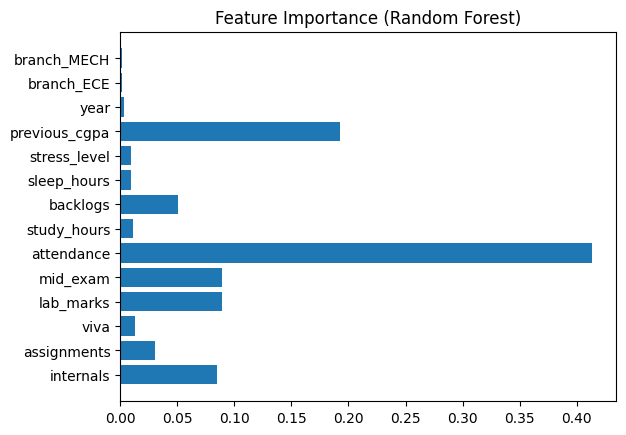

In [14]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()


===== MODEL PERFORMANCE =====
                Model       MAE        R2  Accuracy
0       RF Regression  2.065108  0.922871       NaN
1      XGB Regression  1.709081  0.949875       NaN
2   RF Classification       NaN       NaN    0.9095
3  XGB Classification       NaN       NaN    0.9180


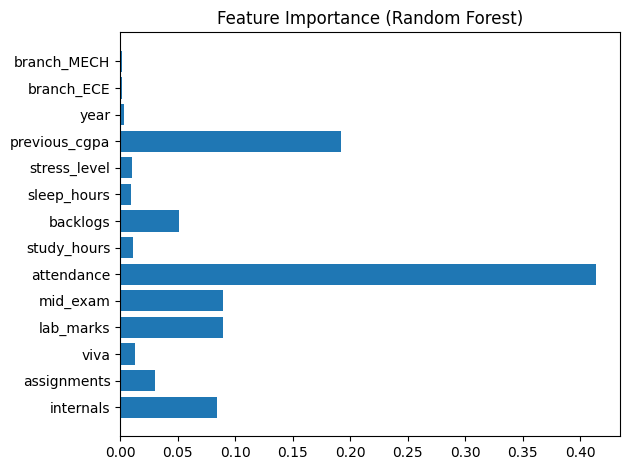

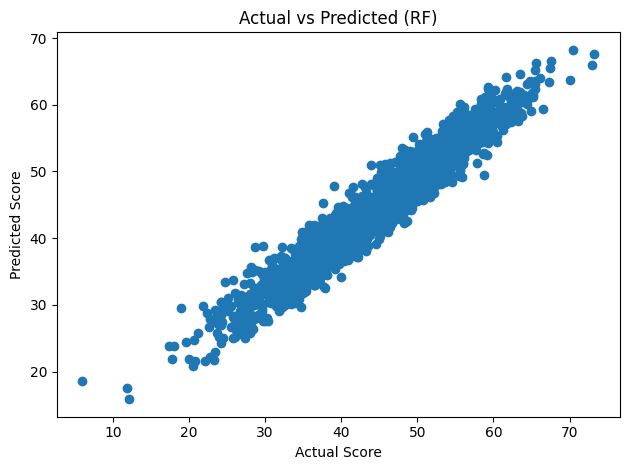

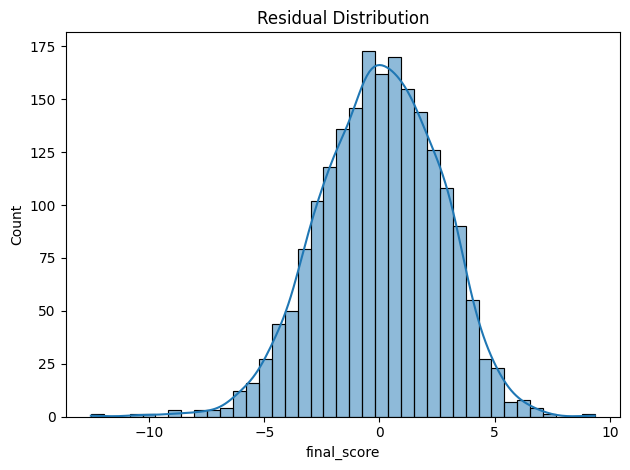

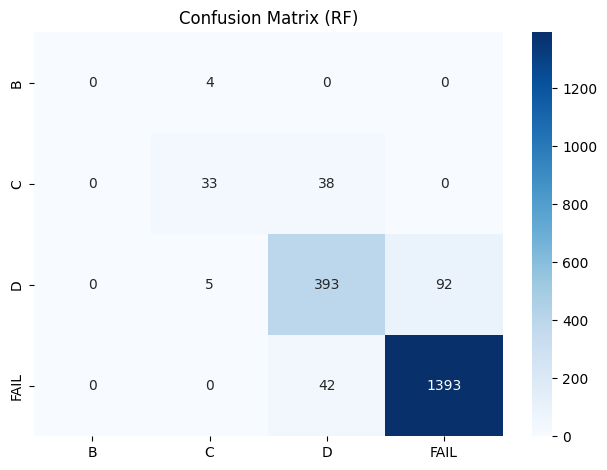

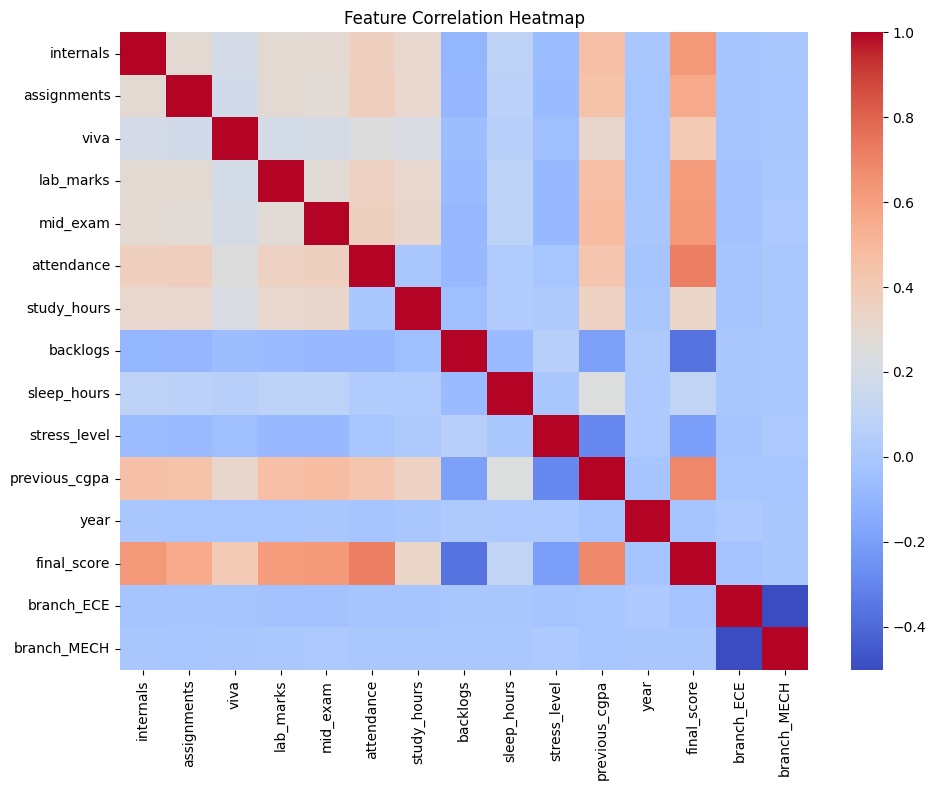


✅ Everything saved:
- model_metrics.csv
- feature_importance.png
- actual_vs_predicted.png
- residual_plot.png
- confusion_matrix.png
- correlation_heatmap.png
- trained models (.pkl)


In [15]:
# ================== ALL-IN-ONE ML PIPELINE ==================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, r2_score,
    accuracy_score, classification_report, confusion_matrix
)
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor, XGBClassifier

# ---------------- LOAD DATA ----------------
data = pd.read_csv("student_performance_dataset.csv")

# ---------------- PREPROCESS ----------------
data = pd.get_dummies(data, columns=["branch"], drop_first=True)
data.fillna(data.mean(numeric_only=True), inplace=True)

# ---------------- FEATURES ----------------
X = data.drop(["final_score", "grade"], axis=1)
y_reg = data["final_score"]
y_clf = data["grade"]

# Encode classification labels
le = LabelEncoder()
y_clf_encoded = le.fit_transform(y_clf)

# ---------------- SPLIT ----------------
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

_, _, y_clf_train, y_clf_test = train_test_split(
    X, y_clf_encoded, test_size=0.2, random_state=42
)

# ---------------- MODELS ----------------
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)

xgb_reg = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_clf = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# ---------------- TRAIN ----------------
rf_reg.fit(X_train, y_reg_train)
rf_clf.fit(X_train, y_clf_train)

xgb_reg.fit(X_train, y_reg_train)
xgb_clf.fit(X_train, y_clf_train)
import joblib
joblib.dump(le, "../ml_results/label_encoder.pkl")

# ---------------- PREDICT ----------------
rf_reg_pred = rf_reg.predict(X_test)
xgb_reg_pred = xgb_reg.predict(X_test)

rf_clf_pred = rf_clf.predict(X_test)
xgb_clf_pred = xgb_clf.predict(X_test)

# ---------------- METRICS ----------------
metrics = {
    "Model": ["RF Regression", "XGB Regression", "RF Classification", "XGB Classification"],
    "MAE": [
        mean_absolute_error(y_reg_test, rf_reg_pred),
        mean_absolute_error(y_reg_test, xgb_reg_pred),
        None,
        None
    ],
    "R2": [
        r2_score(y_reg_test, rf_reg_pred),
        r2_score(y_reg_test, xgb_reg_pred),
        None,
        None
    ],
    "Accuracy": [
        None,
        None,
        accuracy_score(y_clf_test, rf_clf_pred),
        accuracy_score(y_clf_test, xgb_clf_pred)
    ]
}

metrics_df = pd.DataFrame(metrics)
metrics_df.to_csv("../ml_results/model_metrics.csv", index=False)

print("\n===== MODEL PERFORMANCE =====")
print(metrics_df)

# ---------------- VISUALIZATIONS ----------------

# 1. Feature Importance
plt.figure()
importances = rf_reg.feature_importances_
plt.barh(X.columns, importances)
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.savefig("../ml_results/feature_importance.png")
plt.show()

# 2. Actual vs Predicted (Regression)
plt.figure()
plt.scatter(y_reg_test, rf_reg_pred)
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted (RF)")
plt.tight_layout()
plt.savefig("../ml_results/actual_vs_predicted.png")
plt.show()

# 3. Residual Plot
plt.figure()
sns.histplot(y_reg_test - rf_reg_pred, kde=True)
plt.title("Residual Distribution")
plt.tight_layout()
plt.savefig("../ml_results/residual_plot.png")
plt.show()

# 4. Confusion Matrix (Classification)
plt.figure()
cm = confusion_matrix(y_clf_test, rf_clf_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title("Confusion Matrix (RF)")
plt.tight_layout()
plt.savefig("../ml_results/confusion_matrix.png")
plt.show()

# 5. Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(numeric_only=True), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("../ml_results/correlation_heatmap.png")
plt.show()

# ---------------- SAVE MODELS ----------------
import joblib
import os
os.makedirs("../ml_results", exist_ok=True)

joblib.dump(rf_reg, "../ml_results/rf_reg_model.pkl")
joblib.dump(xgb_reg, "../ml_results/xgb_reg_model.pkl")
joblib.dump(rf_clf, "../ml_results/rf_clf_model.pkl")
joblib.dump(xgb_clf, "../ml_results/xgb_clf_model.pkl")

print("\n✅ Everything saved:")
print("- model_metrics.csv")
print("- feature_importance.png")
print("- actual_vs_predicted.png")
print("- residual_plot.png")
print("- confusion_matrix.png")
print("- correlation_heatmap.png")
print("- trained models (.pkl)")

In [16]:
import zipfile
import os

# Files to include
files_to_zip = [
    "model_metrics.csv",
    "feature_importance.png",
    "actual_vs_predicted.png",
    "residual_plot.png",
    "confusion_matrix.png",
    "correlation_heatmap.png",
    "rf_reg_model.pkl",
    "xgb_reg_model.pkl",
    "rf_clf_model.pkl",
    "xgb_clf_model.pkl"
]

zip_filename = "ml_results.zip"

with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in files_to_zip:
        if os.path.exists(file):
            zipf.write(file)

print(f"✅ ZIP file created: {zip_filename}")

✅ ZIP file created: ml_results.zip


In [17]:
import zipfile
import os

# List of trained model files to include in the new zip
model_files_to_zip = [
    "rf_reg_model.pkl",
    "xgb_reg_model.pkl",
    "rf_clf_model.pkl",
    "xgb_clf_model.pkl"
]

zip_filename_models = "ml_models.zip"

with zipfile.ZipFile(zip_filename_models, 'w') as zipf:
    for file in model_files_to_zip:
        if os.path.exists(file):
            zipf.write(file)

print(f"✅ ZIP file created: {zip_filename_models} containing only the ML models.")

✅ ZIP file created: ml_models.zip containing only the ML models.
